# **Introduction**

The goal of this notebook was to implement K-Fold Cross-validation on top of the L-SFAN model. Since this was built on top of the initial L-SFAN model, it is **recommend** to through the file "Transformer_and_L-SFAN.ipynb" to get a better understanding.

Note that since it did not seem to show stronger results, for reasons that could come from multiple factors, this model was never updated to match the latest L-SFAN implementation.

Implementation
*   L-SFAN
*   5-Fold Cross-Validation
*   Ensemble

Highest Public Score
*   0.9091 (13/11/2025)




In [ ]:
# @title Running the notebook

# Please put the 'pirate_pain_train.csv', 'pirate_pain_train_labels.csv' and 'pirate_pain_test.csv' next to this notebook on Google Drive
# Change <CURRENT_DIR> to the location of this notebook
CURRENT_DIR = '/content/drive/MyDrive/INSERT_CURRENT_DIRECTORY_PATH'

# **Environment Setup**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")
%cd $CURRENT_DIR

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1PimcAM1-EdQIcNJGtvMRvNjVE1tqGDRc/Challenge_1/Mathieu


In [ ]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os


# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
logs_dir = "tensorboard"
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

PyTorch version: 2.8.0+cu126
Device: cuda


# Preprocessing

In [ ]:
# Read the dataset into a DataFrame with specified column names
data = pd.read_csv('data/pirate_pain_train.csv', header=0)
data.head(10)

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


In [ ]:
#read dataset with labels
label_df=pd.read_csv('data/pirate_pain_train_labels.csv', header=0)
label_df.head(10)

,sample_index,label
0,0,no_pain
1,1,no_pain
2,2,low_pain
3,3,no_pain
4,4,no_pain
5,5,no_pain
6,6,no_pain
7,7,no_pain
8,8,no_pain
9,9,no_pain


In [ ]:
#merge labels with dataset
df = data.merge(label_df, on="sample_index", how="left", validate="m:1")

print(df["label"].value_counts())
df.head(10)

label
no_pain      81760
low_pain     15040
high_pain     8960
Name: count, dtype: int64


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0,0,2,0,2,1,two,two,two,1.094705,...,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,0,1,2,2,2,2,two,two,two,1.135183,...,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,no_pain
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,no_pain
3,0,3,2,2,2,2,two,two,two,0.938017,...,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,no_pain
4,0,4,2,2,2,2,two,two,two,1.090185,...,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,no_pain
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5,no_pain
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5,no_pain
7,0,7,2,2,2,2,two,two,two,1.038597,...,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5,no_pain
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5,no_pain
9,0,9,0,2,2,2,two,two,two,1.054999,...,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5,no_pain


In [ ]:
#Counting how many pirates are present in the dataset
print("Pirates:", len(np.unique(df['sample_index'])))

order = ["no_pain", "low_pain", "high_pain"]

#Counting the labels per class
pirate_labels = df.groupby("sample_index")["label"].first()

counts = pirate_labels.value_counts()
total = len(pirate_labels)

for cls in order:
    count = counts.get(cls, 0)
    pct = (count / total) * 100
    print(f"{cls}: {count} ({pct:.2f}%)")

Pirates: 661
no_pain: 511 (77.31%)
low_pain: 94 (14.22%)
high_pain: 56 (8.47%)


In [ ]:
#Print the shape of the DataFrame
print(f"DataFrame shape: {df.shape}")
#Print Summary
df.info()


DataFrame shape: (105760, 41)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  int64  
 1   time           105760 non-null  int64  
 2   pain_survey_1  105760 non-null  int64  
 3   pain_survey_2  105760 non-null  int64  
 4   pain_survey_3  105760 non-null  int64  
 5   pain_survey_4  105760 non-null  int64  
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float64
 10  joint_01       105760 non-null  float64
 11  joint_02       105760 non-null  float64
 12  joint_03       105760 non-null  float64
 13  joint_04       105760 non-null  float64
 14  joint_05       105760 non-null  float64
 15  joint_06       105760 non-null  float64
 16  joint_07       105760 non-null  float64
 17 

In [ ]:
#convert to float32
df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).astype(np.float32)
#Print Summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   n_legs         105760 non-null  object 
 7   n_hands        105760 non-null  object 
 8   n_eyes         105760 non-null  object 
 9   joint_00       105760 non-null  float32
 10  joint_01       105760 non-null  float32
 11  joint_02       105760 non-null  float32
 12  joint_03       105760 non-null  float32
 13  joint_04       105760 non-null  float32
 14  joint_05       105760 non-null  float32
 15  joint_06       105760 non-null  float32
 16  joint_07       105760 non-null  float32
 17  joint_08       105760 non-nul

In [ ]:
#show a row for each pirate
first_rows_per_sample = (
    df.drop_duplicates(subset="sample_index", keep="first")
      .head(10)
      .reset_index(drop=True)
)

first_rows_per_sample

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label
0,0.0,0.0,2.0,0.0,2.0,1.0,two,two,two,1.094705,...,1.945042e-06,3.999558e-06,1.153299e-05,3.805930e-06,0.017592,0.013508,0.026798,0.027815,0.5,no_pain
1,1.0,0.0,2.0,1.0,2.0,2.0,two,two,two,1.233603,...,1.790415e-07,3.006389e-07,6.997916e-08,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5,no_pain
2,2.0,0.0,1.0,1.0,1.0,2.0,two,two,two,0.170677,...,1.183228e-06,2.236364e-06,9.688514e-08,5.987389e-07,0.193762,0.115937,0.039989,0.032033,0.5,low_pain
3,3.0,0.0,1.0,2.0,2.0,0.0,two,two,two,0.996243,...,1.802904e-06,2.588236e-06,1.715739e-06,5.349919e-06,0.017648,0.044323,0.045728,0.041061,0.5,no_pain
4,4.0,0.0,2.0,2.0,0.0,0.0,two,two,two,0.972103,...,2.407151e-06,1.974214e-06,8.159604e-08,0.000000e+00,0.002939,0.015767,0.017016,0.021965,0.5,no_pain
5,5.0,0.0,2.0,0.0,2.0,2.0,two,two,two,1.126637,...,1.661360e-07,2.826171e-07,4.248218e-08,6.992469e-06,0.014098,0.051534,0.012429,0.051722,0.5,no_pain
6,6.0,0.0,2.0,0.0,2.0,2.0,two,two,two,1.101345,...,9.419276e-07,3.239535e-07,8.933957e-07,0.000000e+00,0.027001,0.144871,0.044796,0.037567,0.5,no_pain
7,7.0,0.0,2.0,2.0,2.0,2.0,two,two,two,1.072391,...,1.772156e-07,2.982113e-07,6.608183e-08,0.000000e+00,0.027947,0.070982,0.027583,0.015155,0.5,no_pain
8,8.0,0.0,2.0,2.0,2.0,2.0,one+peg_leg,one+hook_hand,one+eye_patch,1.044719,...,6.372409e-07,4.913076e-07,1.275396e-06,1.013391e-04,0.006518,0.009533,0.021116,0.036020,0.5,no_pain
9,9.0,0.0,2.0,0.0,2.0,2.0,two,two,two,0.987456,...,1.803519e-07,2.622896e-07,1.462642e-08,3.784606e-06,0.005788,0.009742,0.012155,0.014311,0.5,no_pain


In [ ]:
#Determine the values of categorical features
print(df["n_legs"].astype(str).str.strip().str.lower().unique())
print(df["n_hands"].astype(str).str.strip().str.lower().unique())
print(df["n_eyes"].astype(str).str.strip().str.lower().unique())

['two' 'one+peg_leg']
['two' 'one+hook_hand']
['two' 'one+eye_patch']


In [ ]:
#Convert categorical features to number
#We ignore the peg_leg, hook_hand and eye_patch as it's propertional

def map_two_to_2_else_1(x):
    return 2 if 'two' in x else 1

df["legs_count"]  = df["n_legs"].apply(map_two_to_2_else_1).astype('float32')
df["hands_count"] = df["n_hands"].apply(map_two_to_2_else_1).astype('float32')
df["eyes_count"]  = df["n_eyes"].apply(map_two_to_2_else_1).astype('float32')

df = df.drop(columns=["n_legs","n_hands","n_eyes"])

In [ ]:
#show convertion
first_rows_per_sample = (
    df.drop_duplicates(subset="sample_index", keep="first")
      .head(10)
      .reset_index(drop=True)
)

first_rows_per_sample

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,legs_count,hands_count,eyes_count
0,0.0,0.0,2.0,0.0,2.0,1.0,1.094705,0.985281,1.018302,1.010385,...,3.805930e-06,0.017592,0.013508,0.026798,0.027815,0.5,no_pain,2.0,2.0,2.0
1,1.0,0.0,2.0,1.0,2.0,2.0,1.233603,1.029888,1.151819,0.964590,...,0.000000e+00,0.038205,0.071314,0.167005,0.071224,0.5,no_pain,2.0,2.0,2.0
2,2.0,0.0,1.0,1.0,1.0,2.0,0.170677,0.000000,0.150608,0.441534,...,5.987389e-07,0.193762,0.115937,0.039989,0.032033,0.5,low_pain,2.0,2.0,2.0
3,3.0,0.0,1.0,2.0,2.0,0.0,0.996243,1.078399,0.932990,0.998395,...,5.349919e-06,0.017648,0.044323,0.045728,0.041061,0.5,no_pain,2.0,2.0,2.0
4,4.0,0.0,2.0,2.0,0.0,0.0,0.972103,0.941107,0.988553,0.934516,...,0.000000e+00,0.002939,0.015767,0.017016,0.021965,0.5,no_pain,2.0,2.0,2.0
5,5.0,0.0,2.0,0.0,2.0,2.0,1.126637,1.038498,0.938397,0.899024,...,6.992469e-06,0.014098,0.051534,0.012429,0.051722,0.5,no_pain,2.0,2.0,2.0
6,6.0,0.0,2.0,0.0,2.0,2.0,1.101345,1.025400,0.942634,0.965327,...,0.000000e+00,0.027001,0.144871,0.044796,0.037567,0.5,no_pain,2.0,2.0,2.0
7,7.0,0.0,2.0,2.0,2.0,2.0,1.072391,0.988676,1.015451,0.891076,...,0.000000e+00,0.027947,0.070982,0.027583,0.015155,0.5,no_pain,2.0,2.0,2.0
8,8.0,0.0,2.0,2.0,2.0,2.0,1.044719,1.033696,1.022788,0.967894,...,1.013391e-04,0.006518,0.009533,0.021116,0.036020,0.5,no_pain,1.0,1.0,1.0
9,9.0,0.0,2.0,0.0,2.0,2.0,0.987456,0.939778,0.845851,0.924030,...,3.784606e-06,0.005788,0.009742,0.012155,0.014311,0.5,no_pain,2.0,2.0,2.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   joint_00       105760 non-null  float32
 7   joint_01       105760 non-null  float32
 8   joint_02       105760 non-null  float32
 9   joint_03       105760 non-null  float32
 10  joint_04       105760 non-null  float32
 11  joint_05       105760 non-null  float32
 12  joint_06       105760 non-null  float32
 13  joint_07       105760 non-null  float32
 14  joint_08       105760 non-null  float32
 15  joint_09       105760 non-null  float32
 16  joint_10       105760 non-null  float32
 17  joint_11       105760 non-nul

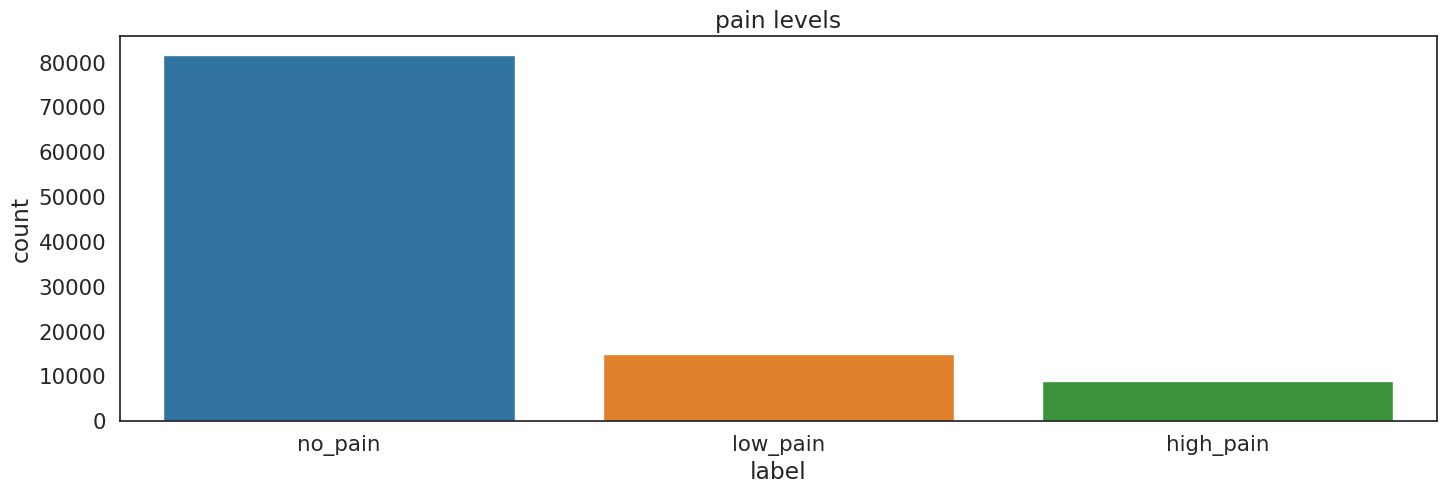

In [ ]:
# Visualise the count of timestamps for each pain level
plt.figure(figsize=(17, 5))
sns.countplot(
    x='label',
    data=df,
    order=df['label'].value_counts().index,
    palette='tab10'
)

# Set the title of the plot
plt.title('pain levels')

# Display the plot
plt.show()

In [ ]:
# count timestamp for each sample_index
per_user_counts = (
    df["sample_index"]
    .value_counts()
    .sort_index()
)


per_user_df = (
    per_user_counts
    .rename_axis("sample_index")
    .reset_index(name="n_timestamps")
)

print(per_user_df.head(30)) # show some
print(f"Number of pirates: {len(per_user_df)}")

    sample_index  n_timestamps
0            0.0           160
1            1.0           160
2            2.0           160
3            3.0           160
4            4.0           160
5            5.0           160
6            6.0           160
7            7.0           160
8            8.0           160
9            9.0           160
10          10.0           160
11          11.0           160
12          12.0           160
13          13.0           160
14          14.0           160
15          15.0           160
16          16.0           160
17          17.0           160
18          18.0           160
19          19.0           160
20          20.0           160
21          21.0           160
22          22.0           160
23          23.0           160
24          24.0           160
25          25.0           160
26          26.0           160
27          27.0           160
28          28.0           160
29          29.0           160
Number of pirates: 661


In [ ]:
#map label to number {0, 1, 2}
class_order = ["no_pain", "low_pain", "high_pain"]
label_map = {c: i for i, c in enumerate(class_order)}

df["label"] = df["label"].map(label_map).astype("int8")


In [ ]:
#Normalize joints angle using min-max normalization

joint_cols = [f"joint_{i:02d}" for i in range(31)]

mins = df[joint_cols].min()
maxs = df[joint_cols].max()
ranges = (maxs - mins).replace(0, 1.0)

df[joint_cols] = (df[joint_cols] - mins) / ranges

In [ ]:
#show a row for each pirate
first_rows_per_sample = (
    df.drop_duplicates(subset="sample_index", keep="first")
      .head(40)
      .reset_index(drop=True)
)

first_rows_per_sample

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,legs_count,hands_count,eyes_count
0,0.0,0.0,2.0,0.0,2.0,1.0,0.777507,0.738252,0.779512,0.804419,...,4.017432e-06,0.014214,0.011376,0.018978,0.020291,0.0,0,2.0,2.0,2.0
1,1.0,0.0,2.0,1.0,2.0,2.0,0.876159,0.771675,0.881821,0.767764,...,0.000000e+00,0.031062,0.060058,0.118273,0.051959,0.0,0,2.0,2.0,2.0
2,2.0,0.0,1.0,1.0,1.0,2.0,0.121223,0.000000,0.114628,0.349093,...,6.320118e-07,0.158212,0.097638,0.028320,0.023369,0.0,1,2.0,2.0,2.0
3,3.0,0.0,1.0,2.0,2.0,0.0,0.707575,0.808024,0.714140,0.794823,...,5.647222e-06,0.014259,0.037327,0.032385,0.029955,0.0,0,2.0,2.0,2.0
4,4.0,0.0,2.0,2.0,0.0,0.0,0.690430,0.705154,0.756716,0.743692,...,0.000000e+00,0.002236,0.013279,0.012051,0.016024,0.0,0,2.0,2.0,2.0
5,5.0,0.0,2.0,0.0,2.0,2.0,0.800186,0.778127,0.718284,0.715282,...,7.381052e-06,0.011357,0.043400,0.008802,0.037733,0.0,0,2.0,2.0,2.0
6,6.0,0.0,2.0,0.0,2.0,2.0,0.782223,0.768312,0.721530,0.768353,...,0.000000e+00,0.021904,0.122005,0.031724,0.027406,0.0,0,2.0,2.0,2.0
7,7.0,0.0,2.0,2.0,2.0,2.0,0.761658,0.740796,0.777327,0.708921,...,0.000000e+00,0.022677,0.059779,0.019534,0.011056,0.0,0,2.0,2.0,2.0
8,8.0,0.0,2.0,2.0,2.0,2.0,0.742005,0.774529,0.782950,0.770409,...,1.069707e-04,0.005161,0.008028,0.014955,0.026277,0.0,0,1.0,1.0,1.0
9,9.0,0.0,2.0,0.0,2.0,2.0,0.701334,0.704158,0.647369,0.735298,...,3.994923e-06,0.004565,0.008204,0.008608,0.010440,0.0,0,2.0,2.0,2.0


In [ ]:
#Verify data normalization
joint_cols = [c for c in df.columns if "joint" in c]
min_max = pd.DataFrame({
    "min": df[joint_cols].min(),
    "max": df[joint_cols].max()
})
print(min_max)

          min  max
joint_00  0.0  1.0
joint_01  0.0  1.0
joint_02  0.0  1.0
joint_03  0.0  1.0
joint_04  0.0  1.0
joint_05  0.0  1.0
joint_06  0.0  1.0
joint_07  0.0  1.0
joint_08  0.0  1.0
joint_09  0.0  1.0
joint_10  0.0  1.0
joint_11  0.0  1.0
joint_12  0.0  1.0
joint_13  0.0  1.0
joint_14  0.0  1.0
joint_15  0.0  1.0
joint_16  0.0  1.0
joint_17  0.0  1.0
joint_18  0.0  1.0
joint_19  0.0  1.0
joint_20  0.0  1.0
joint_21  0.0  1.0
joint_22  0.0  1.0
joint_23  0.0  1.0
joint_24  0.0  1.0
joint_25  0.0  1.0
joint_26  0.0  1.0
joint_27  0.0  1.0
joint_28  0.0  1.0
joint_29  0.0  1.0
joint_30  0.0  0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105760 entries, 0 to 105759
Data columns (total 41 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   sample_index   105760 non-null  float32
 1   time           105760 non-null  float32
 2   pain_survey_1  105760 non-null  float32
 3   pain_survey_2  105760 non-null  float32
 4   pain_survey_3  105760 non-null  float32
 5   pain_survey_4  105760 non-null  float32
 6   joint_00       105760 non-null  float32
 7   joint_01       105760 non-null  float32
 8   joint_02       105760 non-null  float32
 9   joint_03       105760 non-null  float32
 10  joint_04       105760 non-null  float32
 11  joint_05       105760 non-null  float32
 12  joint_06       105760 non-null  float32
 13  joint_07       105760 non-null  float32
 14  joint_08       105760 non-null  float32
 15  joint_09       105760 non-null  float32
 16  joint_10       105760 non-null  float32
 17  joint_11       105760 non-nul

In [ ]:
from sklearn.model_selection import train_test_split

VAL_RATIO = 0.2

def split_train_val(df, val_ratio=0.2, seed=42):

    # one label per pirate
    per_user = (
        df.drop_duplicates("sample_index")[["sample_index", "label"]]
          .rename(columns={"sample_index": "user", "label": "y"})
    )

    ids    = per_user["user"].to_numpy()
    labels = per_user["y"].to_numpy()

    # stratified split by label
    train_ids, val_ids, y_train, y_val = train_test_split(
        ids, labels,
        test_size=val_ratio,
        stratify=labels,
        random_state=seed,
    )

    # build subsets
    df_train = df[df["sample_index"].isin(train_ids)].copy()
    df_val   = df[df["sample_index"].isin(val_ids)].copy()

    # report sizes and balance
    print("Train:", df_train.shape, "Val:", df_val.shape)

    def dist_per_user(d):
        return (
            d.drop_duplicates("sample_index")["label"]
             .value_counts().sort_index().to_dict()
        )

    print("Distribution of pirates per class:")
    print("  Train:", dist_per_user(df_train))
    print("  Val  :", dist_per_user(df_val))

    return df_train, df_val


df_train, df_val = split_train_val(df, val_ratio=VAL_RATIO, seed=SEED)

Train: (84480, 41) Val: (21280, 41)
Distribution of pirates per class:
  Train: {0: 408, 1: 75, 2: 45}
  Val  : {0: 103, 1: 19, 2: 11}


In [ ]:
#Define the window size
WINDOW_SIZE = 160 # 1 window for every pirate

#Define the stride for overlapping windows
STRIDE = 40

In [ ]:
def build_sequences_pirate(
    df: pd.DataFrame,
    label_col="label",
    id_col="sample_index",
    time_col="time",
    feature_cols=None,
    window=160,
    stride=40,
    pad_value=0.0,
    pad_side="end",
):
    assert window % stride == 0, "window must be multiple of stride"


    if feature_cols is None:
        exclude = {id_col, time_col, label_col}
        feature_cols = [
            c for c in df.select_dtypes(include=[np.number]).columns
            if c not in exclude
        ]

    sequences, labels = [], []

    # Iteration for pirate
    for pid, g in df.groupby(id_col):
        g = g.sort_values(time_col, kind="stable")
        X = g[feature_cols].to_numpy(dtype=np.float32)

        # label for patient
        y_vals = g[label_col].dropna().unique()
        y = y_vals[0]

        # padding: 0 if already multiple
        pad_len = (-len(X)) % window
        if pad_len:
            pad_block = np.full((pad_len, X.shape[1]), pad_value, dtype=np.float32)
            X = np.vstack([pad_block, X]) if pad_side == "start" else np.vstack([X, pad_block])

        # finestre scorrevoli
        for start in range(0, len(X) - window + 1, stride):
            end = start + window
            sequences.append(X[start:end])
            labels.append(y)

    return np.asarray(sequences, dtype=np.float32), np.asarray(labels)


In [ ]:
# Create data sequences
X_train, y_train = build_sequences_pirate(
    df=df_train,
    window=WINDOW_SIZE,
    stride=STRIDE
)

X_val, y_val = build_sequences_pirate(
    df=df_val,
    window=WINDOW_SIZE,
    stride=STRIDE
)


print("Training data")
print(X_train.shape)  # (n_windows, window_size, n_features)
print(y_train.shape)  # (n_windows,)

print("Validation data")
print(X_val.shape)  # (n_windows, window_size, n_features)
print(y_val.shape)  # (n_windows,)

Training data
(528, 160, 38)
(528,)
Validation data
(133, 160, 38)
(133,)


In [ ]:
# Define the input shape based on the training data
input_shape = X_train.shape[1:]

# Define the number of classes based on the categorical labels
num_classes = len(np.unique(y_train))

In [ ]:
# Convert numpy arrays to PyTorch datasets (pairs features with labels)
train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

In [ ]:
# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 128

In [ ]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Determine optimal number of worker processes for data loading
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    # Create DataLoader with performance optimizations
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,  # Faster GPU transfer
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,  # Load 4 batches ahead
    )

In [ ]:
# Create data loaders with different settings for each phase
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

In [ ]:
import json

# Save data to files
def save_all(
    out_dir,
    df_train, df_val,
    X_train, y_train, X_val, y_val,
    mins, ranges, feature_cols,
    class_order=("no_pain","low_pain","high_pain"),
    y_dtype_np="int32"  # "int64" se usi PyTorch
):
    os.makedirs(out_dir, exist_ok=True)

    # 1) DataFrame preprocessed
    df_train.to_parquet(os.path.join(out_dir, "train_preprocessed.parquet"), index=False)
    df_val.to_parquet(  os.path.join(out_dir, "val_preprocessed.parquet"),   index=False)

    # 2) Parameters (fit su train)
    norm_info = {
        "scale_columns": list(mins.index),
        "mins":   {k: float(v) for k, v in mins.to_dict().items()},
        "ranges": {k: float(v) for k, v in ranges.to_dict().items()},
    }
    with open(os.path.join(out_dir, "normalization.json"), "w") as f:
        json.dump(norm_info, f, indent=2)

    # 3) Map classes
    with open(os.path.join(out_dir, "class_map.json"), "w") as f:
        json.dump({"class_order": list(class_order)}, f, indent=2)

    # 4) Features
    with open(os.path.join(out_dir, "feature_cols.json"), "w") as f:
        json.dump({"feature_cols": list(feature_cols)}, f, indent=2)

    # 5) Sequenze (NPZ compresso)
    np.savez_compressed(
        os.path.join(out_dir, "train_sequences.npz"),
        X=X_train.astype(np.float32),
        y=y_train.astype(y_dtype_np)
    )
    np.savez_compressed(
        os.path.join(out_dir, "val_sequences.npz"),
        X=X_val.astype(np.float32),
        y=y_val.astype(y_dtype_np)
    )

    print(f"All saved: {out_dir}")

#actual save
out_dir = "code"

feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in {"sample_index", "time", "label"}
  ]

save_all(
    out_dir=out_dir,
    df_train=df_train, df_val=df_val,
    X_train=X_train, y_train=y_train,
    X_val=X_val,     y_val=y_val,
    mins=mins, ranges=ranges,
    feature_cols=feature_cols,
    class_order=("no_pain","low_pain","high_pain"),
    y_dtype_np="int32"
)


All saved: code


# Model Building

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
from datetime import datetime
import math

In [ ]:
class ConvBlock(nn.Module):
    """
    Convolutional block: Conv -> BatchNorm -> ReLU -> Conv -> BatchNorm -> ReLU -> MaxPool
    """
    def __init__(self, in_channels, out_channels, kernel_size=(3, 3), pool_size=(2, 1)):
        super().__init__()

        # First conv layer
        self.conv1 = nn.Conv2d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            padding=(kernel_size[0]//2, kernel_size[1]//2)  # Same padding
        )
        self.bn1 = nn.BatchNorm2d(out_channels)

        # Second conv layer
        self.conv2 = nn.Conv2d(
            out_channels, out_channels,
            kernel_size=kernel_size,
            padding=(kernel_size[0]//2, kernel_size[1]//2)
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Max pooling (only reduces temporal dimension)
        self.pool = nn.MaxPool2d(kernel_size=pool_size, stride=pool_size)

        self.relu = nn.ReLU()

    def forward(self, x):
        # First conv block
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        # Second conv block
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        # Pooling
        x = self.pool(x)
        return x

In [ ]:
class MultiHeadSelfAttention(nn.Module):
    """
    Multi-head self-attention module for L-SFAN
    """
    def __init__(self, embed_dim, num_heads=5, dropout=0.2):
        super().__init__()

        assert embed_dim % num_heads == 0, f"embed_dim ({embed_dim}) must be divisible by num_heads ({num_heads})"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        # Linear projections for Q, K, V
        self.q_linear = nn.Linear(embed_dim, embed_dim)
        self.k_linear = nn.Linear(embed_dim, embed_dim)
        self.v_linear = nn.Linear(embed_dim, embed_dim)

        # Output projection
        self.out_linear = nn.Linear(embed_dim, embed_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        """
        Args:
            x: [batch, embed_dim]
        Returns:
            output: [batch, embed_dim]
        """
        batch_size = x.size(0)

        # Add sequence dimension: [batch, embed_dim] -> [batch, 1, embed_dim]
        x = x.unsqueeze(1)

        # Linear projections
        Q = self.q_linear(x)  # [batch, 1, embed_dim]
        K = self.k_linear(x)
        V = self.v_linear(x)

        # Split into multiple heads
        # [batch, 1, embed_dim] -> [batch, num_heads, 1, head_dim]
        Q = Q.view(batch_size, 1, self.num_heads, self.head_dim).transpose(1, 2)
        K = K.view(batch_size, 1, self.num_heads, self.head_dim).transpose(1, 2)
        V = V.view(batch_size, 1, self.num_heads, self.head_dim).transpose(1, 2)

        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Apply attention to values
        attn_output = torch.matmul(attn_weights, V)  # [batch, num_heads, 1, head_dim]

        # Concatenate heads
        attn_output = attn_output.transpose(1, 2).contiguous()  # [batch, 1, num_heads, head_dim]
        attn_output = attn_output.view(batch_size, 1, self.embed_dim)  # [batch, 1, embed_dim]

        # Output projection
        output = self.out_linear(attn_output)
        output = output.squeeze(1)  # [batch, embed_dim]

        return output

In [ ]:
#L-SFAN data
class PiratePainLSFAN(nn.Module):
    """
    L-SFAN architecture adapted for Pirate Pain Dataset

    Input: [batch, 160, 38] - YOUR data format
    Output: [batch, 3] - 3 pain classes

    Key changes for 661 samples:
    - Adjusted for 38 features
    - Optimized channel sizes for your dataset
    - Dropout tuned for 661 samples
    """

    def __init__(
        self,
        n_timesteps=160,
        n_features=38,          # ← YOUR feature count
        n_classes=3,
        conv1_channels=8,       # Start with 8 (was 4 for 160 samples)
        conv2_channels=16,      # Then 16 (original L-SFAN size)
        num_attention_heads=5,  # Keep 5 as in paper
        dropout=0.2             # Lower dropout for 661 samples
    ):
        super().__init__()

        self.n_timesteps = n_timesteps
        self.n_features = n_features

        print(f"\n{'='*70}")
        print(f"Creating L-SFAN Model")
        print(f"{'='*70}")
        print(f"Input: [{n_timesteps} timesteps × {n_features} features]")

        # ===== CNN FEATURE EXTRACTOR =====

        # Conv Block 1: [batch, 1, 160, 38] -> [batch, 8, 160, 38] -> [batch, 8, 80, 38]
        self.conv_block1 = ConvBlock(
            in_channels=1,
            out_channels=conv1_channels,
            kernel_size=(3, 3),
            pool_size=(2, 1)  # Only reduce temporal: 160 -> 80
        )
        print(f"After Conv Block 1: [batch, {conv1_channels}, 80, {n_features}]")

        # Conv Block 2: [batch, 8, 80, 38] -> [batch, 16, 80, 38] -> [batch, 16, 40, 38]
        self.conv_block2 = ConvBlock(
            in_channels=conv1_channels,
            out_channels=conv2_channels,
            kernel_size=(3, 3),
            pool_size=(2, 1)  # Only reduce temporal: 80 -> 40
        )
        print(f"After Conv Block 2: [batch, {conv2_channels}, 40, {n_features}]")

        # Calculate dimensions after convolutions
        temporal_after_conv = n_timesteps // 4  # 160 -> 40
        spatial_after_conv = n_features  # 38 (unchanged)

        # ===== TEMPORAL AVERAGE POOLING (TAP) - L-SFAN's Key Innovation! =====
        # Pool over TIME, keep SPATIAL (feature) dimension
        self.temporal_pool = nn.AdaptiveAvgPool2d((1, spatial_after_conv))
        print(f"After TAP: [batch, {conv2_channels}, 1, {spatial_after_conv}]")

        # Flatten to get spatial feature vector
        self.flatten_dim = conv2_channels * spatial_after_conv
        print(f"After Flatten: [batch, {self.flatten_dim}]")

        # ===== MULTI-HEAD SELF-ATTENTION =====
        self.attention = MultiHeadSelfAttention(
            embed_dim=self.flatten_dim,
            num_heads=num_attention_heads,
            dropout=dropout
        )
        print(f"After Attention: [batch, {self.flatten_dim}]")

        # Feed-forward after attention
        self.feed_forward = nn.Sequential(
            nn.Linear(self.flatten_dim, self.flatten_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ===== CLASSIFICATION HEAD =====
        # Larger head for 661 samples (can handle more capacity)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.flatten_dim, self.flatten_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(self.flatten_dim // 2, n_classes)
        )
        print(f"Output: [batch, {n_classes}]")

        # Initialize weights
        self._init_weights()

        total_params = self.count_parameters()
        print(f"\n✅ L-SFAN Created Successfully!")
        print(f"   Total Parameters: {total_params:,}")
        print(f"   Conv1 channels: {conv1_channels}")
        print(f"   Conv2 channels: {conv2_channels}")
        print(f"   Attention heads: {num_attention_heads}")
        print(f"   Dropout: {dropout}")
        print(f"{'='*70}\n")

    def _init_weights(self):
        """Xavier initialization for better training stability"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def forward(self, x):
        """
        Forward pass

        Args:
            x: [batch, seq_len, n_features] = [batch, 160, 41]
               This is YOUR data format from the DataLoader

        Returns:
            logits: [batch, n_classes] = [batch, 3]
        """
        batch_size = x.size(0)

        # ===== CREATE 2D "IMAGE" REPRESENTATION =====
        # YOUR data: [batch, 160, 38]
        # Add channel dimension: [batch, 1, 160, 38]
        # Now it's like a grayscale image:
        #   - Height: 160 (time)
        #   - Width: 38 (features)
        x = x.unsqueeze(1)

        # ===== CNN FEATURE EXTRACTION =====
        x = self.conv_block1(x)  # [batch, 8, 80, 38]
        x = self.conv_block2(x)  # [batch, 16, 40, 38]

        # ===== TEMPORAL AVERAGE POOLING (TAP) =====
        # L-SFAN's key innovation: pool over time, keep spatial
        # This emphasizes SPATIAL patterns (which features relate)
        # over TEMPORAL patterns (how they change over time)
        x = self.temporal_pool(x)  # [batch, 16, 1, 38]

        # ===== FLATTEN SPATIAL FEATURES =====
        x = x.view(batch_size, -1)  # [batch, 16*38] = [batch, 608]

        # ===== MULTI-HEAD SELF-ATTENTION =====
        # Refines spatial features by finding relationships
        x_attn = self.attention(x)  # [batch, 608]

        # ===== FEED-FORWARD WITH RESIDUAL =====
        x = self.feed_forward(x_attn) + x  # [batch, 608]

        # ===== CLASSIFICATION =====
        logits = self.classifier(x)  # [batch, 3]

        return logits

In [ ]:
# Build the Model

DROPOUT=0.2
NUM_ATTENTION_HEADS=8

lsfan_model = PiratePainLSFAN(
  n_timesteps=160,
  n_features=38,
  n_classes=3,
  conv1_channels=8,
  conv2_channels=16,
  num_attention_heads=NUM_ATTENTION_HEADS,
  dropout=DROPOUT
)


Creating L-SFAN Model
Input: [160 timesteps × 38 features]
After Conv Block 1: [batch, 8, 80, 38]
After Conv Block 2: [batch, 16, 40, 38]
After TAP: [batch, 16, 1, 38]
After Flatten: [batch, 608]
After Attention: [batch, 608]
Output: [batch, 3]

✅ L-SFAN Created Successfully!
   Total Parameters: 2,041,659
   Conv1 channels: 8
   Conv2 channels: 16
   Attention heads: 8
   Dropout: 0.2



# Model Training

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Train for one epoch WITHOUT data augmentation

    Args:
        model: PyTorch model
        dataloader: Training DataLoader
        criterion: Loss function
        optimizer: Optimizer
        device: 'cuda' or 'cpu'

    Returns:
        avg_loss: Average loss for the epoch
        accuracy: Training accuracy
        f1: Macro F1 score
    """
    model.train()  # Set model to training mode

    total_loss = 0
    all_preds = []
    all_labels = []

    for features, labels in dataloader:
        features = features.to(device, non_blocking=True).float()
        labels = labels.to(device, non_blocking=True).long()
        # Handle mask if present (for variable-length sequences)
        # mask = batch['mask'].to(device) if 'mask' in batch else None

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        logits = model(features)

        # Calculate loss
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()

        # Gradient clipping (prevents exploding gradients)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Update weights
        optimizer.step()

        # Track metrics
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    # Calculate epoch metrics
    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1

In [ ]:
def validate(model, dataloader, criterion, device):
    """Validation"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device, non_blocking=True).float()
            labels = labels.to(device, non_blocking=True).long()

            logits = model(features)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='macro')

    return avg_loss, accuracy, f1, all_preds, all_labels

In [ ]:
class EarlyStopping:
    """Early stopping with model checkpointing"""

    def __init__(self, patience=15, min_delta=0.0, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_model_state = None

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            self.best_model_state = copy.deepcopy(model.state_dict())
            return False

        if self.mode == 'min':
            score_improved = score < self.best_score - self.min_delta
        else:
            score_improved = score > self.best_score + self.min_delta

        if score_improved:
            self.best_score = score
            self.best_model_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

        return self.early_stop

In [ ]:
#Custom loss function that replaces the standard nn.CrossEntropyLoss

class LabelSmoothingCrossEntropy(nn.Module):
    """Label smoothing regularization"""

    def __init__(self, smoothing=0.1):
        super().__init__()
        self.smoothing = smoothing

    def forward(self, pred, target):
        n_classes = pred.size(-1)
        log_probs = F.log_softmax(pred, dim=-1)

        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)

        return torch.mean(torch.sum(-true_dist * log_probs, dim=-1))

In [ ]:
class FocalLoss(nn.Module):
    """
    Focal Loss - automatically down-weights easy examples (no_pain)
    and focuses on hard examples (low_pain, high_pain)

    Paper: "Focal Loss for Dense Object Detection"
    """
    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        """
        Args:
            alpha: Class weights (optional, can combine with class weights)
            gamma: Focusing parameter (2.0 is standard, higher = more focus on hard examples)
        """
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        """
        Args:
            inputs: [batch, n_classes] - raw logits
            targets: [batch] - class indices
        """
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-ce_loss)  # Probability of true class

        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [ ]:
def train_model(
    model,
    train_loader,
    val_loader,
    n_epochs=150,
    device='cuda',
    learning_rate=3e-4,
    max_learning_rate=1e-3,
    class_weights=None,
    min_epochs=100,
    focal_loss=False,
    gamma=2.0,
    label_smoothing=0.1,
    patience=20
):
    """Complete training pipeline for 661 samples"""
    model = model.to(device)

    # Loss with label smoothing
    if focal_loss:
        print("Using focal loss")
        criterion = FocalLoss(
        alpha=class_weights,
        gamma=gamma
    )
    elif label_smoothing > 0:
        criterion = LabelSmoothingCrossEntropy(smoothing=label_smoothing)
    else:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device) if class_weights is not None else None)

    # Optimizer with weight decay only to the right parameters
    decay_params = []
    no_decay_params = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
          continue
        if "bias" in name or "norm" in name.lower():
          no_decay_params.append(param)
        else:
          decay_params.append(param)
    optimizer = AdamW(
        [
            {"params": decay_params, "weight_decay": 0.01},
            {"params": no_decay_params, "weight_decay": 0.0}
        ],
        lr=learning_rate,
        betas=(0.9, 0.999)
    )

    # Cosine annealing scheduler TODO
    '''
    scheduler = CosineAnnealingWarmRestarts(
        optimizer,
        T_0=10,
        T_mult=2,
        eta_min=1e-6
    )
    '''
    scheduler = OneCycleLR(
      optimizer,
      max_lr=max_learning_rate,
      epochs=n_epochs,
      steps_per_epoch=len(train_loader),
      pct_start=0.3,  # 30% of training for warmup
      anneal_strategy='cos'
    )

    # Early stopping
    early_stopping = EarlyStopping(patience, mode='min')

    history = {
        'train_loss': [], 'train_acc': [], 'train_f1': [],
        'val_loss': [], 'val_acc': [], 'val_f1': [],
        'lr': []
    }

    print("="*70)
    print("Starting L-SFAN Training (661 samples)")
    print("="*70)
    print(f"Training samples: {len(train_loader.dataset)}")
    print(f"Validation samples: {len(val_loader.dataset)}")
    print(f"Model parameters: {model.count_parameters():,}")
    print(f"Label smoothing: {label_smoothing}")
    print("="*70)

    for epoch in range(n_epochs):
        # Train
        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Validate
        val_loss, val_acc, val_f1, val_preds, val_labels = validate(
            model, val_loader, criterion, device
        )

        # Step scheduler
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        # Update writer
        writer.add_scalar('Loss/train', train_loss, epoch)
        writer.add_scalar('Loss/val', val_loss, epoch)
        writer.add_scalar('Accuracy/train', train_acc, epoch)
        writer.add_scalar('Accuracy/val', val_acc, epoch)
        writer.add_scalar('F1/train', train_f1, epoch)
        writer.add_scalar('F1/val', val_f1, epoch)

        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"\nEpoch {epoch+1}/{n_epochs}")
            print(f"  LR: {current_lr:.6f}")
            print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {train_f1:.4f}")
            print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.4f}, F1: {val_f1:.4f}")
            print(f"  Overfitting gap: {train_acc - val_acc:.4f}")

        # Early stopping
        if early_stopping(val_loss, model) and epoch >= min_epochs:
            print(f"\n{'='*70}")
            print(f"Early stopping at epoch {epoch+1}")
            print(f"{'='*70}")
            model.load_state_dict(early_stopping.best_model_state)
            break

    # Final evaluation
    print(f"\n{'='*70}")
    print("Training Completed!")
    print(f"{'='*70}")

    _, val_acc, val_f1, val_preds, val_labels = validate(model, val_loader, criterion, device)

    print(f"\nBest Validation Metrics:")
    print(f"  Accuracy: {val_acc:.4f}")
    print(f"  Macro F1: {val_f1:.4f}")

    print(f"\nClassification Report:")
    print(classification_report(
        val_labels, val_preds,
        target_names=['no_pain', 'low_pain', 'high_pain'],
        digits=4
    ))

    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(val_labels, val_preds)
    print(cm)

    writer.close()

    return model, history

In [ ]:
def create_writer(run_name):
  log_dir = f"runs/{run_name}"
  print("Logging to: ", log_dir)
  return SummaryWriter(log_dir=log_dir)

In [ ]:
# Train L-SFAN

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Compute the class weights
classes = np.unique(y_train)
class_counts = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = torch.tensor(class_counts, dtype=torch.float).to(device)

learning_rate=8e-4
max_learning_rate=1e-3
min_epochs=100
label_smoothing=0.1

run_name = f"lsfan_lr={learning_rate}_dropout={DROPOUT}_heads={NUM_ATTENTION_HEADS}_"+ datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"Run name: {run_name}")
writer = create_writer(run_name)

trained_lsfan, history = train_model(
  model=lsfan_model,
  train_loader=train_loader,
  val_loader=val_loader,
  n_epochs=500,
  device=device,
  learning_rate=learning_rate,
  max_learning_rate=max_learning_rate,
  class_weights=class_weights,
  min_epochs=min_epochs,
  label_smoothing=label_smoothing,
  patience=20
)

# Save model
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_name = f"lsfan_{timestamp}.pth"
torch.save(trained_lsfan.state_dict(), model_name)
print(f"\n✅ Model saved to {model_name}")

Using device: cuda
Run name: lsfan_lr=0.0008_dropout=0.2_heads=8_20251117_182459
Logging to:  runs/lsfan_lr=0.0008_dropout=0.2_heads=8_20251117_182459
Starting L-SFAN Training (661 samples)
Training samples: 528
Validation samples: 133
Model parameters: 2,041,659
Label smoothing: 0.1

Epoch 1/500
  LR: 0.000040
  Train - Loss: 1.8095, Acc: 0.1818, F1: 0.1753
  Val   - Loss: 1.0684, Acc: 0.7744, F1: 0.2910
  Overfitting gap: -0.5926

Epoch 10/500
  LR: 0.000040
  Train - Loss: 0.8328, Acc: 0.7500, F1: 0.3622
  Val   - Loss: 0.6180, Acc: 0.7744, F1: 0.2910
  Overfitting gap: -0.0244

Epoch 20/500
  LR: 0.000042
  Train - Loss: 0.7111, Acc: 0.7992, F1: 0.4731
  Val   - Loss: 0.5666, Acc: 0.8346, F1: 0.5715
  Overfitting gap: -0.0353

Epoch 30/500
  LR: 0.000044
  Train - Loss: 0.6536, Acc: 0.8542, F1: 0.6379
  Val   - Loss: 0.5487, Acc: 0.8496, F1: 0.6628
  Overfitting gap: 0.0045

Epoch 40/500
  LR: 0.000047
  Train - Loss: 0.5866, Acc: 0.8826, F1: 0.7125
  Val   - Loss: 0.5338, Acc: 0.8

In [ ]:
from collections import Counter

def k_fold_train_lsfan(df, feature_cols, k=5, n_val_users=None, batch_size=128,
                       n_classes=3, conv1_channels=8, conv2_channels=16,
                       num_attention_heads=8, dropout=0.2,
                       learning_rate=8e-4, max_learning_rate=1e-3,
                       n_epochs=500, min_epochs=100, label_smoothing=0.1,
                       patience=20, device='cuda', seed=42,
                       verbose=1,
                       augment_minority=True,
                       augmentation_factor=1.5,
                       noise_std=0.01):
    """
    K-Fold user-based cross-validation for L-SFAN on pirate dataset with optional
    data augmentation for minority classes.
    """
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if device == 'cuda':
        torch.cuda.manual_seed_all(seed)

    unique_users = df['sample_index'].unique()
    if n_val_users is None:
        n_val_users = max(1, int(len(unique_users) * 0.2))

    fold_histories = []
    fold_models = []

    np.random.shuffle(unique_users)
    folds = np.array_split(unique_users, k)

    for fold_idx in range(k):
        if verbose:
            print(f"\n{'='*40}\nFold {fold_idx+1}/{k}")

        val_users = folds[fold_idx]
        train_users = np.concatenate([f for i,f in enumerate(folds) if i != fold_idx])

        df_train = df[df['sample_index'].isin(train_users)].copy()
        df_val   = df[df['sample_index'].isin(val_users)].copy()

        # Compute class weights
        y_train = df_train['label'].to_numpy()
        classes = np.unique(y_train)
        class_counts = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weights = torch.tensor(class_counts, dtype=torch.float).to(device)

        # Build sequences
        X_train, y_train = build_sequences_pirate(df_train, feature_cols=feature_cols)
        X_val, y_val     = build_sequences_pirate(df_val, feature_cols=feature_cols)

        # # --- Data augmentation for minority classes ---
        # if augment_minority:
        #     counter = Counter(y_train)
        #     max_count = max(counter.values())

        #     X_aug_list = []
        #     y_aug_list = []

        #     for cls, count in counter.items():
        #         # Determine how many extra samples to create
        #         n_to_add = int((max_count - count) * augmentation_factor)
        #         if n_to_add <= 0:
        #             continue

        #         # Get all sequences of this class
        #         X_cls = X_train[y_train == cls]

        #         # Randomly sample with replacement
        #         idxs = np.random.choice(len(X_cls), size=n_to_add, replace=True)
        #         X_new = X_cls[idxs].copy()

        #         # Add small noise
        #         X_new += np.random.normal(0, noise_std, X_new.shape).astype(np.float32)

        #         y_new = np.full(n_to_add, cls, dtype=np.int32)

        #         X_aug_list.append(X_new)
        #         y_aug_list.append(y_new)

        #     if X_aug_list:
        #         X_train = np.concatenate([X_train] + X_aug_list, axis=0)
        #         y_train = np.concatenate([y_train] + y_aug_list, axis=0)

        #     # Shuffle after augmentation
        #     perm = np.random.permutation(len(X_train))
        #     X_train, y_train = X_train[perm], y_train[perm]
        #     if verbose:
        #         print(f"  Augmented training set shape: {X_train.shape}, class distribution: {Counter(y_train)}")

        # Datasets & loaders
        train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train))
        val_ds   = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val))

        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
        val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, drop_last=False)

        # Initialize L-SFAN
        model = PiratePainLSFAN(
            n_timesteps=X_train.shape[1],
            n_features=X_train.shape[2],
            n_classes=n_classes,
            conv1_channels=conv1_channels,
            conv2_channels=conv2_channels,
            num_attention_heads=num_attention_heads,
            dropout=dropout
        )

        # Train
        model, history = train_model(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            n_epochs=n_epochs,
            device=device,
            learning_rate=learning_rate,
            max_learning_rate=max_learning_rate,
            class_weights=class_weights,
            min_epochs=min_epochs,
            label_smoothing=label_smoothing,
            patience=patience
        )

        fold_histories.append(history)
        fold_models.append(model)

        fold_model_name = f"lsfan_fold{fold_idx}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pth"
        torch.save(model.state_dict(), fold_model_name)
        print(f"✅ Fold {fold_idx + 1} model saved to models/{fold_model_name}")

    return fold_histories, fold_models


In [ ]:
# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Parameters
k = 5
batch_size = 128
conv1_channels = 8
conv2_channels = 16
num_attention_heads = 8
dropout = 0.2
learning_rate = 8e-4
max_learning_rate = 1e-3
n_epochs = 500
min_epochs = 100
label_smoothing = 0 # So class_weights matter
patience = 20

run_name = f"lsfan_lr={learning_rate}_dropout={DROPOUT}_heads={NUM_ATTENTION_HEADS}_"+ datetime.now().strftime('%Y%m%d_%H%M%S')
print(f"Run name: {run_name}")
writer = create_writer(run_name)

# Run K-Fold training
fold_histories, fold_models = k_fold_train_lsfan(
    df=df,
    feature_cols=feature_cols,
    k=k,
    batch_size=batch_size,
    conv1_channels=conv1_channels,
    conv2_channels=conv2_channels,
    num_attention_heads=num_attention_heads,
    dropout=dropout,
    learning_rate=learning_rate,
    max_learning_rate=max_learning_rate,
    n_epochs=n_epochs,
    min_epochs=min_epochs,
    label_smoothing=label_smoothing,
    patience=patience,
    device=device,
    seed=42,
    verbose=1
)

Using device: cuda
Run name: lsfan_lr=0.0008_dropout=0.2_heads=8_20251117_182629
Logging to:  runs/lsfan_lr=0.0008_dropout=0.2_heads=8_20251117_182629

Fold 1/5

Creating L-SFAN Model
Input: [160 timesteps × 38 features]
After Conv Block 1: [batch, 8, 80, 38]
After Conv Block 2: [batch, 16, 40, 38]
After TAP: [batch, 16, 1, 38]
After Flatten: [batch, 608]
After Attention: [batch, 608]
Output: [batch, 3]

✅ L-SFAN Created Successfully!
   Total Parameters: 2,041,659
   Conv1 channels: 8
   Conv2 channels: 16
   Attention heads: 8
   Dropout: 0.2

Starting L-SFAN Training (661 samples)
Training samples: 528
Validation samples: 133
Model parameters: 2,041,659
Label smoothing: 0

Epoch 1/500
  LR: 0.000040
  Train - Loss: 1.5772, Acc: 0.1667, F1: 0.1701
  Val   - Loss: 1.1043, Acc: 0.0827, F1: 0.0540
  Overfitting gap: 0.0840

Epoch 10/500
  LR: 0.000040
  Train - Loss: 1.1208, Acc: 0.4792, F1: 0.3949
  Val   - Loss: 0.9286, Acc: 0.7218, F1: 0.5326
  Overfitting gap: -0.2426

Epoch 20/500


# Submission

In [ ]:
def scale_test(df, out_dir):

  # load the normalization info
  with open(os.path.join(out_dir, "normalization.json"), "r") as f:
    norm_info = json.load(f)

  scale_columns = norm_info["scale_columns"]
  mins = pd.Series(norm_info["mins"])
  ranges = pd.Series(norm_info["ranges"])

  df[scale_columns] = (
      df[scale_columns] - mins
  )/ranges

  return df

In [ ]:
def preprocess_samples(file_path):
  # Read the dataset into a DataFrame with specified column names
  df = pd.read_csv(file_path, header=0)
  out_dir = CURRENT_DIR + "/code"

  # Counting how many pirates are present in the testset
  print("Pirates:", len(np.unique(df['sample_index'])))

  # Print the shape of the DataFrame
  print(f"DataFrame shape: {df.shape}")

  # Convert to float32
  df[df.select_dtypes(include=[np.number]).columns] = df.select_dtypes(include=[np.number]).astype(np.float32)

  #Convert categorical features to number
  #We ignore the peg_leg, hook_hand and eye_patch as it's propertional

  def map_two_to_2_else_1(x):
      return 2 if 'two' in x else 1

  df["legs_count"]  = df["n_legs"].apply(map_two_to_2_else_1).astype('float32')
  df["hands_count"] = df["n_hands"].apply(map_two_to_2_else_1).astype('float32')
  df["eyes_count"]  = df["n_eyes"].apply(map_two_to_2_else_1).astype('float32')

  df = df.drop(columns=["n_legs","n_hands","n_eyes"])

  # count timestamp for each sample_index
  per_user_counts = (
      df["sample_index"]
      .value_counts()
      .sort_index()
  )


  per_user_df = (
      per_user_counts
      .rename_axis("sample_index")
      .reset_index(name="n_timestamps")
  )

  print(per_user_df.head(30))       # show some
  print(len(per_user_df), "number of pirates")

  # scaling
  df_scaled = scale_test(df, out_dir)

  with open(f"{out_dir}/feature_cols.json", "r") as f:
    feature_cols = json.load(f)["feature_cols"]

  # Make sure rows are ordered correctly
  df_test = df_scaled.sort_values(["sample_index", "time"])

  groups = df_test.groupby("sample_index")
  sample_ids = groups.size().index.to_numpy()  # unique sample_index values

  X_test = np.stack([
      g[feature_cols].to_numpy()   # shape (160, n_features) for each subject
      for _, g in groups
  ])  # final shape: (num_subjects, 160, n_features)

  print("X_test shape:", X_test.shape)
  return X_test, sample_ids

In [ ]:
def predict(model, test_loader, device):
    """
    Use an already-trained model to get class indices and probabilities for the test set.
    """
    model.eval()
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            # batch is a tuple because we used TensorDataset(X_test)
            # so batch[0] contains the features
            xb = batch[0].to(device).float()      # [batch, 160, n_features]

            # Forward pass
            logits = model(xb)                    # [batch, n_classes]

            probs = torch.softmax(logits, dim=1)  # [batch, n_classes]
            preds = probs.argmax(dim=1)           # [batch]

            all_preds.append(preds.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_probs = np.concatenate(all_probs, axis=0)

    return all_preds, all_probs



In [ ]:
def submit(indexes, labels, key):
  submission = pd.DataFrame({
    "sample_index": indexes,
    "label": labels
  })
  #sort by sample index to be neat
  submission = submission.sort_values("sample_index")
  submission["sample_index"] = submission["sample_index"].map(
      lambda x: f"{int(x):03d}"
  )
  timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
  path = f"submission_{key}_{timestamp}.csv"
  submission.to_csv(path, index=False)
  print(submission.head())
  print(f"Saved submission to: {path}")

In [ ]:
X_test, sample_ids = preprocess_samples(CURRENT_DIR + "/data/pirate_pain_test.csv")

# convert to tensors
X_test_tensor = torch.from_numpy(X_test).float()

# carry indices so we can reconstruct sample_index per prediction
idx_tensor = torch.arange(len(sample_ids))

test_ds = TensorDataset(X_test_tensor, idx_tensor)
test_loader = make_loader(test_ds, batch_size=124, shuffle=False, drop_last=False)



Pirates: 1324
DataFrame shape: (211840, 40)
    sample_index  n_timestamps
0            0.0           160
1            1.0           160
2            2.0           160
3            3.0           160
4            4.0           160
5            5.0           160
6            6.0           160
7            7.0           160
8            8.0           160
9            9.0           160
10          10.0           160
11          11.0           160
12          12.0           160
13          13.0           160
14          14.0           160
15          15.0           160
16          16.0           160
17          17.0           160
18          18.0           160
19          19.0           160
20          20.0           160
21          21.0           160
22          22.0           160
23          23.0           160
24          24.0           160
25          25.0           160
26          26.0           160
27          27.0           160
28          28.0           160
29          29.0          

In [ ]:
# RUN ONLY IF YOU WANT TO EXTRACT A SINGULAR FOLD
# DEFINE best_kfold_lsfan TO BE THE BEST FOLD

"""
models_to_submit = {"5fcv-lfsan": best_kfold_lsfan}
class_order = ["no_pain", "low_pain", "high_pain"]
idx_to_label = {i: name for i, name in enumerate(class_order)}

for key, model in models_to_submit.items():
  model.eval()
  test_pred_indeces, test_pred_probs = predict(model, test_loader, device)
  predicted_labels = [idx_to_label[i] for i in test_pred_indeces]
  submit(sample_ids, predicted_labels, key)
"""

print('optional cell')

optional cell


In [ ]:
models_to_ensemble = fold_models  # list of trained fold models
for model in models_to_ensemble:
    model.eval()  # make sure all models are in eval mode

idx_to_label = {0: "no_pain", 1: "low_pain", 2: "high_pain"}

all_probs = []

with torch.no_grad():
    for model in models_to_ensemble:
        _, probs = predict(model, test_loader, device)  # probs shape: (num_samples, num_classes)
        all_probs.append(probs)

# Average the probabilities across folds
ensemble_probs = np.mean(all_probs, axis=0)

# Take argmax to get predicted class indices
ensemble_pred_indices = np.argmax(ensemble_probs, axis=1)
ensemble_pred_labels = [idx_to_label[i] for i in ensemble_pred_indices]

# Submit
models_to_submit = {"l-sfan-ensemble": "ensemble"}
submit(sample_ids, ensemble_pred_labels, "l-sfan-ensemble")

  sample_index    label
0          000  no_pain
1          001  no_pain
2          002  no_pain
3          003  no_pain
4          004  no_pain
Saved submission to: submission_l-sfan-ensemble_20251117_183412.csv
